## Figures for CASA007 Lecture 3

This nb generates the figures for Lecture 3 - Hypothesis Testing. All figs generated are saved to the folder 'L3_images'. 

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch, Circle
import numpy as np
import textwrap

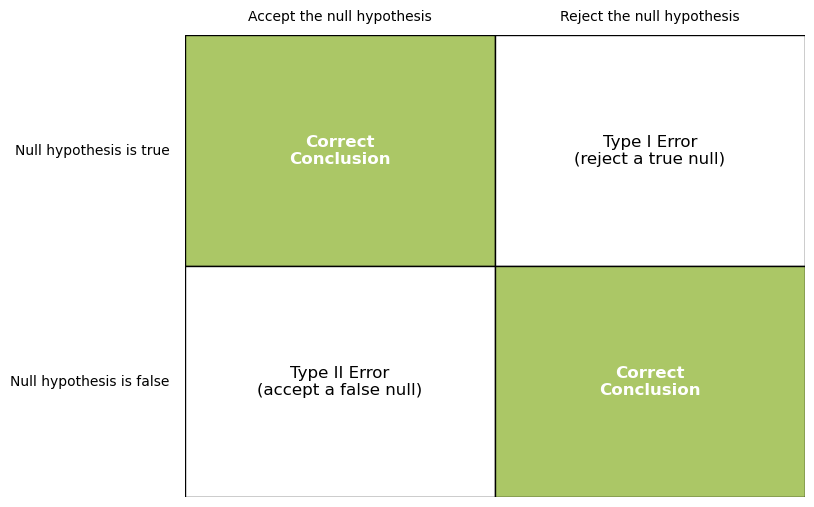

In [5]:
fig, ax = plt.subplots(figsize=(8,6))

# Draw rectangles
ax.add_patch(patches.Rectangle((0,1), 1, 1, facecolor="#abc766", edgecolor="black"))  # Top left
ax.add_patch(patches.Rectangle((1,1), 1, 1, facecolor="white", edgecolor="black"))    # Top right
ax.add_patch(patches.Rectangle((0,0), 1, 1, facecolor="white", edgecolor="black"))    # Bottom left
ax.add_patch(patches.Rectangle((1,0), 1, 1, facecolor="#abc766", edgecolor="black"))  # Bottom right

# Add text
ax.text(0.5, 1.5, "Correct\nConclusion", ha="center", va="center", color="white", fontsize=12, weight="bold")
ax.text(1.5, 1.5, "Type I Error\n(reject a true null)", ha="center", va="center", color="black", fontsize=12)
ax.text(0.5, 0.5, "Type II Error\n(accept a false null)", ha="center", va="center", color="black", fontsize=12)
ax.text(1.5, 0.5, "Correct\nConclusion", ha="center", va="center", color="white", fontsize=12, weight="bold")

# Axis labels
ax.set_xlim(0,2)
ax.set_ylim(0,2)
ax.axis("off")

# Add arrows and labels for rows/columns
ax.annotate("Conclusion from\nstatistical analysis", xy=(0.5,2.05), xytext=(1,2.3),
            ha="center", fontsize=12, color="blue", arrowprops=dict(arrowstyle="->"))
ax.text(0.5, 2.05, "Accept the null hypothesis", ha="center", va="bottom", fontsize=10)
ax.text(1.5, 2.05, "Reject the null hypothesis", ha="center", va="bottom", fontsize=10)

ax.annotate("The true state\nof nature", xy=(-0.3,1), xytext=(-0.8,1),
            ha="center", fontsize=12, color="blue", arrowprops=dict(arrowstyle="->"))
ax.text(-0.05, 1.5, "Null hypothesis is true", ha="right", va="center", fontsize=10)
ax.text(-0.05, 0.5, "Null hypothesis is false", ha="right", va="center", fontsize=10)

plt.savefig("L3_images/error_matrix.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()


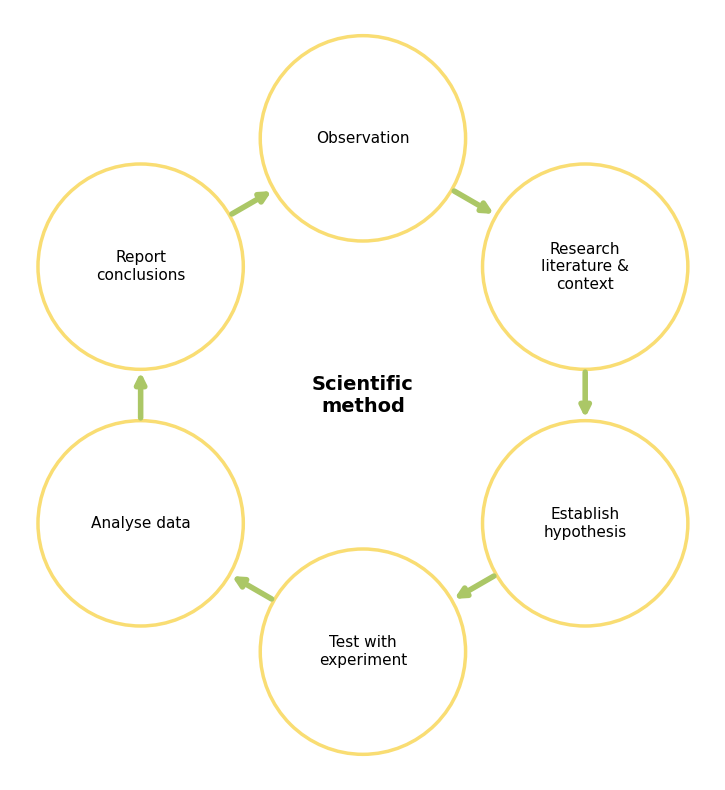

In [3]:
# Labels for the scientific method
labels = [
    "Observation",
    "Research literature & context",
    "Establish hypothesis",
    "Test with experiment",
    "Analyse data",
    "Report conclusions"
]

# Circle positions (arranged around a circle)
angles = [90, 30, -30, -90, -150, 150]  # degrees
radius = 4
positions = [(radius * np.cos(np.radians(a)), radius * np.sin(np.radians(a))) for a in angles]

fig, ax = plt.subplots(figsize=(10,10))

node_radius = 1.6

# Draw nodes (circles with text)
for (x, y), label in zip(positions, labels):
    circ = Circle((x, y), node_radius, facecolor="white", edgecolor="#f9dd73", lw=2.5)
    ax.add_patch(circ)
    
    # Wrap text to fit inside circle
    wrapped = textwrap.fill(label, width=14)  # tweak width if needed
    ax.text(x, y, wrapped, ha="center", va="center", fontsize=11)

# Draw arrows connecting nodes
for i in range(len(positions)):
    x1, y1 = positions[i]
    x2, y2 = positions[(i+1) % len(positions)]
    
    dx, dy = x2 - x1, y2 - y1
    dist = (dx**2 + dy**2)**0.5
    dx /= dist
    dy /= dist
    
    start = (x1 + dx*node_radius, y1 + dy*node_radius)
    end = (x2 - dx*node_radius, y2 - dy*node_radius)
    
    arrow = FancyArrowPatch(
        posA=start, posB=end,
        arrowstyle='-|>',
        mutation_scale=15,
        linewidth=4,
        color="#abc766"
    )
    ax.add_patch(arrow)

# Central text
ax.text(0, 0, "Scientific\nmethod", ha="center", va="center", fontsize=14, weight="bold")

# Formatting
ax.set_aspect("equal")
ax.axis("off")
ax.set_xlim(-radius-1.5, radius+1.5)
ax.set_ylim(-radius-2, radius+2)

# Save with transparent background
plt.savefig("L3_images/scientific_method.png", dpi=200, transparent=True)
plt.show()


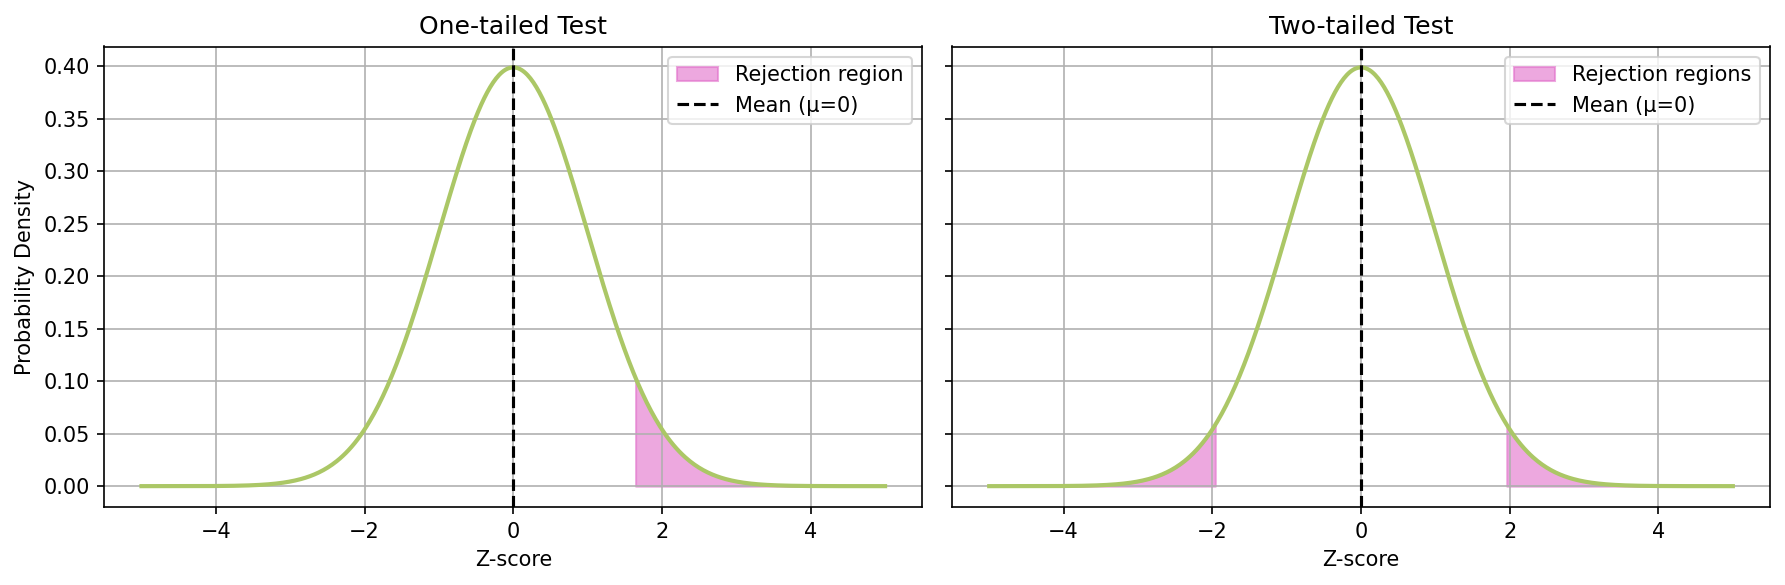

In [2]:
# Generate data
x = np.linspace(-5, 5, 500)
y = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x**2)

# Figure setup
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=150, sharey=True)

# Parameters
mean = 0
std_dev = 1

# --- One-tailed test ---
axes[0].plot(x, y, color="#abc766", lw=2)
axes[0].set_title("One-tailed Test")
axes[0].set_xlabel("Z-score")
axes[0].set_ylabel("Probability Density")
axes[0].grid(True)

# Shade right tail (critical z = 1.645 for α = 0.05)
x_fill = np.linspace(1.645, 5, 200)
y_fill = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x_fill**2)
axes[0].fill_between(x_fill, y_fill, color="#e16fca", alpha=0.6, label="Rejection region")

axes[0].axvline(mean, color="black", linestyle='--', label="Mean (μ=0)")
axes[0].legend()

# --- Two-tailed test ---
axes[1].plot(x, y, color="#abc766", lw=2)
axes[1].set_title("Two-tailed Test")
axes[1].set_xlabel("Z-score")
axes[1].grid(True)

# Shade left tail (critical z = -1.96 for α = 0.05/2)
x_fill_left = np.linspace(-5, -1.96, 200)
y_fill_left = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x_fill_left**2)
axes[1].fill_between(x_fill_left, y_fill_left, color="#e16fca", alpha=0.6)

# Shade right tail (critical z = 1.96)
x_fill_right = np.linspace(1.96, 5, 200)
y_fill_right = (1 / (np.sqrt(2 * np.pi))) * np.exp(-0.5 * x_fill_right**2)
axes[1].fill_between(x_fill_right, y_fill_right, color="#e16fca", alpha=0.6, label="Rejection regions")

axes[1].axvline(mean, color="black", linestyle='--', label="Mean (μ=0)")
axes[1].legend()

# Layout and save
plt.tight_layout()
plt.savefig("L3_images/one_vs_two_tailed.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()


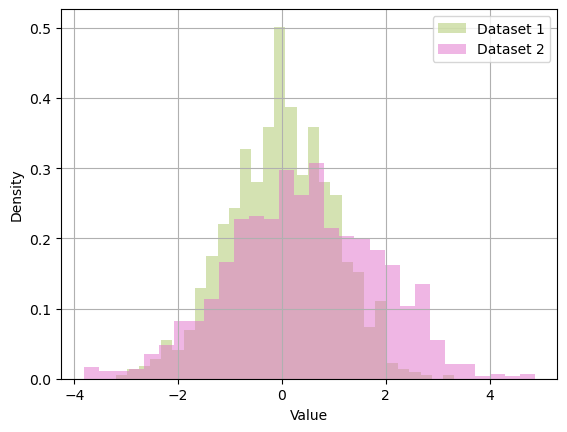

In [3]:
# plot two overlayed histograms with transparency to illustrate kolmogorov-smirnov test
data1 = np.random.normal(loc=0, scale=1, size=1000)
data2 = np.random.normal(loc=0.5, scale=1.5, size=1000)
plt.hist(data1, bins=30, alpha=0.5, label='Dataset 1', color='#abc766', density=True)
plt.hist(data2, bins=30, alpha=0.5, label='Dataset 2', color='#e16fca', density=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.savefig("L3_images/overlayed_histograms.png", dpi=300, bbox_inches='tight', transparent=True)
plt.show()